# Capstone Project

## Superconducting quantum circuits at the surface code threshold for fault tolerance

**Author : Murat Can Sarihan, Google Quantum AI**

**References**

1. Barends, R. et al. Coherent Josephson Qubit Suitable for Scalable Quantum Integrated Circuits. Phys Rev Lett 111, 080502 (2013).
2. Barends, R. et al. Superconducting quantum circuits at the surface code threshold for fault tolerance. Nature 508, 500–503 (2014).
  

In this task, we will design one of the important devices in the history of superconducting quantum computing. In Barends et al. (2014), John Martinis and his team, which will build the foundations of Google Quantum AI lab shortly after, demonstrated a full set of 1Q and 2Q gates with fidelities above the fault-tolerance threshold required for surface code error correction. The result made quantum error correction with surface codes is not only a proposal but a serious possibility, which is demonstrated later.

The team achieved an average single-qubit gate fidelity of 99.92% and a two-qubit gate fidelity of up to 99.4% by designing a 5-qubit linear array quantum processor, with tunable transmons (Xmon) and fixed coupling.

During this task, we will attempt to build the same device that enabled the later advancements. We will be using the circuit elements we designed during the workshop, and integrate to create the device given in Figure 1.

![Architecture. (a) Optical image of the integrated Josephson quantum processor, consisting of Al (dark) on sapphire (light). The five cross-shaped devices are the Xmon variant of the transmon qubit13 , labelled Q0 − Q4 , placed in a linear array. To the left of the qubits are five meandering coplanar waveguide resonators used for individual state readout. Control wiring is brought in from the contact pads at the edge of the chip, ending at the right of the qubits. (b) Circuit diagram. Our architecture employs direct, nearestneighbour coupling of the qubits (red/orange), made possible by the nodal connectivity of the Xmon qubit. Using a single readout line, each qubit can be measured using frequency-domain multiplexing (blue). Individual qubits are driven through capacitively-coupled microwave control lines (XY), and frequency control is achieved through inductively-coupled dc lines (Z) (purple). (c) Schematic representation of an entangling operation using a controlled-Z gate with unitary representation UCZ : (I) Qubits at rest, at distinct frequencies with minimal interaction. (II) When brought near resonance, the state-dependent frequency shift brings about a rotation conditional on the qubit states. (III) Qubits are returned to their rest frequency.](../../assets/1.jpg)

**Figure 1: Architecture**. (a) Optical image of the integrated Josephson quantum processor, consisting of Al (dark) on sapphire (light). The five cross-shaped devices are the Xmon variant of the transmon qubit13 , labelled Q0 − Q4 , placed in a linear array. To the left of the qubits are five meandering coplanar waveguide resonators used for individual state readout. Control wiring is brought in from the contact pads at the edge of the chip, ending at the right of the qubits. (b) Circuit diagram. Our architecture employs direct, nearestneighbour coupling of the qubits (red/orange), made possible by the nodal connectivity of the Xmon qubit. Using a single readout line, each qubit can be measured using frequency-domain multiplexing (blue). Individual qubits are driven through capacitively-coupled microwave control lines (XY), and frequency control is achieved through inductively-coupled dc lines (Z) (purple). (c) Schematic representation of an entangling operation using a controlled-Z gate with unitary representation UCZ : (I) Qubits at rest, at distinct frequencies with minimal interaction. (II) When brought near resonance, the state-dependent frequency shift brings about a rotation conditional on the qubit states. (III) Qubits are returned to their rest frequency.

The processor has five qubits in a 1-D chain with maximum qubit frequency alternating between 5.8 GHz and 5 GHz approximately. The average nonlinearity, eta, of the qubits are around 215 MHz, while the coupling strength between two neighboring qubits are 30 MHz at 4.7 GHz. The qubits are apart from each other, enough to have 1.3 MHz next-nearest neighbour coupling strength.

# Solution - 5-Qubit Josephson Processor Layout

In this section, we implement the layout design for the 5-qubit linear transmon processor. We place the qubits horizontally, couple them to a single readout feedline via meandered resonators (frequency-staggered), and route the XY and Z control lines to the bottom edge of the chip.

In [3]:
%load_ext autoreload
%autoreload 2
%config IPCompleter.greedy = True
%matplotlib inline
%config Completer.use_jedi = False
%config InlineBackend.figure_format = 'svg'

## 1. Setup and Environment Initialization

Initialize `DesignPlanar` with a substrate size of $6.0\,\text{mm} \times 6.0\,\text{mm}$.

In [4]:
import os
os.environ['QISKIT_METAL_HEADLESS'] = 'True'

import numpy as np


import qiskit_metal as metal
from qiskit_metal import designs, Dict
from qiskit_metal.qlibrary.qubits.transmon_cross import TransmonCross
from qiskit_metal.qlibrary.qubits.transmon_cross_fl import TransmonCrossFL
from qiskit_metal.qlibrary.couplers.coupled_line_tee import CoupledLineTee
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.tlines.straight_path import RouteStraight
from qiskit_metal.qlibrary.tlines.framed_path import RouteFramed
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
from qiskit_metal.qlibrary.tlines.anchored_path import RouteAnchors
from qiskit_metal.qlibrary.lumped.cap_n_interdigital import CapNInterdigital

import matplotlib.pyplot as plt
from qiskit_metal.renderers.renderer_mpl.mpl_renderer import QMplRenderer

# Instantiate Design
design = designs.DesignPlanar()
design.chips.main.size.size_x = '6.0mm'
design.chips.main.size.size_y = '6.0mm'

print("Design initialized with a 6x6 mm substrate.")


Design initialized with a 6x6 mm substrate.


## 2. Placer Qubits (Q0 to Q4)

We place 5 `TransmonCross` qubits horizontally with a pitch of $1.5\,\text{mm}$ along the $x$-axis. This close proximity creates nearest-neighbor capacitive coupling between the arms of the cross shape islands.

Each qubit is configured with three ports:
- `readout` (North arm, location `90`)
- `XY` (West arm, location `0`)
- `Z` (South arm, location `270`)

In [5]:
design.delete_all_components()
design.overwrite_enabled = True
qubit_pitch = 0.45  # mm pitch
qubits = []
xy_pads = []
for i in range(5):
    x_pos = (i - 2) * qubit_pitch
    q = TransmonCrossFL(design, f'Q{i}', options=dict(
        pos_x=f'{x_pos}mm',
        pos_y='0.0mm',
        orientation='0',
        cross_width='30um',
        cross_length='190um',
        cross_gap='50um',
        make_fl =True,
        fl_options = dict(
            t_gap='3um', 
            t_inductive_gap='3um', 
            t_offset='0um', 
            t_top='15um', 
            t_width='5um',
        ),
        connection_pads=dict(
            readout = dict(
                connector_type='0', 
                claw_length='40um', 
                ground_spacing='5um', 
                claw_width='10um', 
                claw_gap='6um', 
                connector_location='90' # North arm
            ),
        )
    ))
    qubits.append(q)

# 1. Place manual XY coupling pads (orientation = 90)

    xy_pad = OpenToGround(design, f'XY_pad_{i}', options=dict(
        pos_x=f'{x_pos - 0.1}mm',
        pos_y='-0.18mm',
        orientation='90',
        width='10um',
        gap='6um',
        termination_gap='6um'
    ))
    xy_pads.append(xy_pad)

print("XY pads placed!")
print("Placed qubits Q0, Q1, Q2, Q3, Q4!")

XY pads placed!
Placed qubits Q0, Q1, Q2, Q3, Q4!


In [6]:
xy_pads

[name:    XY_pad_0
 class:   OpenToGround          
 options: 
   'pos_x'             : '-1.0mm',                     
   'pos_y'             : '-0.18mm',                    
   'orientation'       : '90',                         
   'chip'              : 'main',                       
   'layer'             : '1',                          
   'width'             : '10um',                       
   'gap'               : '6um',                        
   'termination_gap'   : '6um',                        
 module:  qiskit_metal.qlibrary.terminations.open_to_ground
 id:      2,
 name:    XY_pad_1
 class:   OpenToGround          
 options: 
   'pos_x'             : '-0.55mm',                    
   'pos_y'             : '-0.18mm',                    
   'orientation'       : '90',                         
   'chip'              : 'main',                       
   'layer'             : '1',                          
   'width'             : '10um',                       
   'gap'         

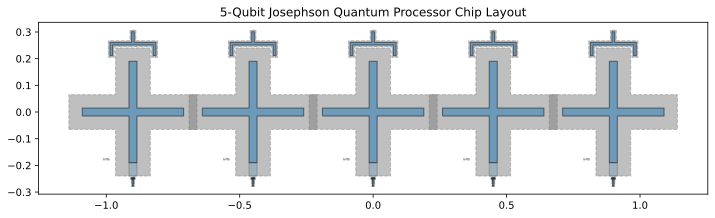

In [7]:
fig, ax = plt.subplots(figsize=(12, 12))
renderer = QMplRenderer(design, logger=design.logger)
renderer.render(ax)

ax.autoscale()
ax.set_aspect('equal')
plt.title("5-Qubit Josephson Quantum Processor Chip Layout")
plt.show()

In [8]:
from pypalace import mesh 

In [10]:
surface_table = mesh.get_quantum_metal_surfaces(design)
names = ["cross","readout_connector_arm"]

attributes = {}
terminals = []
mesh_attr_num = 1
for i in range(5):
    qubit_name = f"Q{i}"
    metal_surfaces = surface_table[(surface_table["component_name"] == qubit_name)]
    comp_id = metal_surfaces.component_id.iloc[0]

    attributes[(comp_id,"cross")] = mesh_attr_num
    terminals.append(mesh_attr_num)
    mesh_attr_num += 1
    attributes[(comp_id,"readout_connector_arm")] = mesh_attr_num
    terminals.append(mesh_attr_num)
    mesh_attr_num += 1

In [11]:
attributes,terminals

({(1, 'cross'): 1,
  (1, 'readout_connector_arm'): 2,
  (3, 'cross'): 3,
  (3, 'readout_connector_arm'): 4,
  (5, 'cross'): 5,
  (5, 'readout_connector_arm'): 6,
  (7, 'cross'): 7,
  (7, 'readout_connector_arm'): 8,
  (9, 'cross'): 9,
  (9, 'readout_connector_arm'): 10},
 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

In [12]:
meshfile = "design_project.msh"
path_to_mesh = meshfile

## mesh the design --> returns pandas.dataframe of labeled mesh attributes ##
## look at readthedocs, mesh_Quantum_Metal_design has a lot of flexibility to control surface mesh size, volume mesh size, substrate size, etc ## 
attributes_table = mesh.mesh_Quantum_Metal_design(design,
                                                  output_mesh=path_to_mesh,
                                                  Attributes=attributes);

Info    : Meshing 1D...                                                                                                                   
Info    : [  0%] Meshing curve 25 (Line)
Info    : [ 10%] Meshing curve 26 (Line)
Info    : [ 10%] Meshing curve 27 (Line)
Info    : [ 10%] Meshing curve 28 (Line)
Info    : [ 10%] Meshing curve 29 (Line)
Info    : [ 10%] Meshing curve 30 (Line)
Info    : [ 10%] Meshing curve 31 (Line)
Info    : [ 10%] Meshing curve 32 (Line)
Info    : [ 10%] Meshing curve 33 (Line)
Info    : [ 10%] Meshing curve 34 (Line)
Info    : [ 10%] Meshing curve 35 (Line)
Info    : [ 10%] Meshing curve 36 (Line)
Info    : [ 10%] Meshing curve 49 (Line)
Info    : [ 10%] Meshing curve 50 (Line)
Info    : [ 10%] Meshing curve 51 (Line)
Info    : [ 10%] Meshing curve 52 (Line)
Info    : [ 10%] Meshing curve 53 (Line)
Info    : [ 10%] Meshing curve 54 (Line)
Info    : [ 10%] Meshing curve 55 (Line)
Info    : [ 10%] Meshing curve 56 (Line)
Info    : [ 10%] Meshing curve 57 (Line)


In [13]:
attributes_table

,Name,ID,Type
0,1__cross,1,Surface
9,9__readout_connector_arm,10,Surface
12,substrate,11,Volume
13,air,12,Volume
10,ground_plane,13,Surface
11,far_field,14,Surface
1,1__readout_connector_arm,2,Surface
2,3__cross,3,Surface
3,3__readout_connector_arm,4,Surface
4,5__cross,5,Surface


In [14]:
substrate_id = 11
air_id = 12
ground_plane_id = 13
far_field_id = 14

In [15]:
from pypalace import Config
from pypalace.builder import Model, Domains, Boundaries, Solver  # these match one-to-one with Palace config syntax

In [16]:
path_to_config = "design_project.json"

In [17]:
electrostatic_config = Config(path_to_config)

In [18]:
electrostatic_config.add_Problem(Type="Electrostatic",
                             Output="design_project_electrostatic_results")

# define config["Model"] block
electrostatic_config.add_Model(Mesh = path_to_mesh,L0 = 1e-6) 

In [19]:

# define materials
silicon = Domains.Material(Attributes = [substrate_id], # attributes to give the properties below to:
                                     Permeability=1.0, # magnetic permeability
                                     Permittivity=11.45, # electric permittivity
                                     LossTan=1e-07) # bulk loss tangent

airbox = Domains.Material([air_id],1.0,1.0,0.0)

# will not use this here but an example of adding domain postprocessing:


materials = [silicon,airbox] # material list for input into add_Domains()
electrostatic_config.add_Domains(Materials = materials) # add materials to our configuration file

In [20]:
BCs = []
for terminal_id in terminals:
    current_terminal = Boundaries.Terminal(Index=terminal_id,Attributes=[terminal_id])
    BCs.append(current_terminal)


grounds = Boundaries.Ground(Attributes=[ground_plane_id,far_field_id])
BCs.append(grounds)

electrostatic_config.add_Boundaries(BCs=BCs)

In [21]:
## electrostatic parameters
electrostatic_params =  Solver.Electrostatic(Save=2)

## linear solver parameters
Linear_params = Solver.Linear(Type="BoomerAMG",
                              KSPType = "CG",
                              Tol = 1e-6, # make more stringent for better results
                              MaxIts = 25) 
                              
electrostatic_config.add_Solver(Simulation=electrostatic_params,
                                Order= 1, # first order solver
                                Linear=Linear_params)

In [98]:
electrostatic_config.save_config(check_validity=True)
electrostatic_config.print_config()

{
  "Problem": {
    "Type": "Electrostatic",
    "Verbose": 2,
    "Output": "design_project_electrostatic_results"
  },
  "Model": {
    "Mesh": "design_project.msh",
    "L0": 1e-06
  },
  "Domains": {
    "Materials": [
      {
        "Attributes": [
          11
        ],
        "Permeability": 1.0,
        "Permittivity": 11.45,
        "LossTan": 1e-07
      },
      {
        "Attributes": [
          12
        ],
        "Permeability": 1.0,
        "Permittivity": 1.0,
        "LossTan": 0.0
      }
    ]
  },
  "Boundaries": {
    "Ground": {
      "Attributes": [
        13,
        14
      ]
    },
    "Terminal": [
      {
        "Index": 1,
        "Attributes": [
          1
        ]
      },
      {
        "Index": 2,
        "Attributes": [
          2
        ]
      },
      {
        "Index": 3,
        "Attributes": [
          3
        ]
      },
      {
        "Index": 4,
        "Attributes": [
          4
        ]
      },
      {
        "Index": 5

In [99]:
from pypalace import Simulation # used to run simulations and extract simulation results 
from pypalace.palace_env import get_palace_executable  # auto-find path_to_palace
from qdw_workshop.palace import install_pypalace_runner, palace_cpu_count

install_pypalace_runner()

In [100]:
path_to_palace = get_palace_executable() 

In [101]:
electrostatic_simulation = Simulation(electrostatic_config,path_to_palace)

In [102]:
mpi_processes = palace_cpu_count()
electrostatic_simulation.run(n=mpi_processes)

Palace completed successfully. Log written to design_project_electrostatic_results/out.log.


In [104]:
cap_matrix = electrostatic_simulation.get_capacitance_matrix()

In [105]:
## relabel cap matrix to have nice readable column/row names

rename_dict = {}

for name in cap_matrix.index:
    if name.endswith("__cross"):
        rename_dict[name] = f"qubit{(int(name.split('__')[0]) - 1)//2}"
    elif name.endswith("__readout_connector_arm"):
        rename_dict[name] = f"claw{(int(name.split('__')[0]) - 1)//2}"
cap_matrix = cap_matrix.rename(index=rename_dict, columns=rename_dict)

In [106]:
cap_matrix

,qubit0,claw0,qubit1,claw1,qubit2,claw2,qubit3,claw3,qubit4,claw4,ground
qubit0,1.080319e-13,-8.357687e-16,-1.719754e-15,-3.109893e-17,-2.523771e-17,-1.485140e-18,-1.158649e-18,-7.600056e-20,-5.768348e-20,-4.080430e-21,-1.054173e-13
claw0,-8.357687e-16,1.178199e-13,-3.048091e-17,-2.978803e-18,-1.357575e-18,-1.332944e-19,-7.001505e-20,-6.158335e-21,-3.615306e-21,-3.143265e-22,-1.169491e-13
qubit1,-1.719754e-15,-3.048091e-17,1.074416e-13,-8.866098e-16,-1.721785e-15,-3.323170e-17,-2.550891e-17,-1.520499e-18,-1.163739e-18,-7.953185e-20,-1.030215e-13
claw1,-3.109893e-17,-2.978803e-18,-8.866098e-16,1.237978e-13,-3.343777e-17,-4.291647e-18,-1.515779e-18,-1.495996e-19,-7.702732e-20,-7.219095e-21,-1.228376e-13
qubit2,-2.523771e-17,-1.357575e-18,-1.721785e-15,-3.343777e-17,1.071767e-13,-9.163577e-16,-1.669610e-15,-3.177550e-17,-2.505564e-17,-1.533746e-18,-1.027505e-13
claw2,-1.485140e-18,-1.332944e-19,-3.323170e-17,-4.291647e-18,-9.163577e-16,1.130431e-13,-3.167082e-17,-4.435188e-18,-1.502311e-18,-1.554640e-19,-1.120498e-13
qubit3,-1.158649e-18,-7.001505e-20,-2.550891e-17,-1.515779e-18,-1.669610e-15,-3.167082e-17,1.072496e-13,-9.042559e-16,-1.750640e-15,-3.512412e-17,-1.028301e-13
claw3,-7.600056e-20,-6.158335e-21,-1.520499e-18,-1.495996e-19,-3.177550e-17,-4.435188e-18,-9.042559e-16,1.130501e-13,-3.399730e-17,-5.167409e-18,-1.120688e-13
qubit4,-5.768348e-20,-3.615306e-21,-1.163739e-18,-7.702732e-20,-2.505564e-17,-1.502311e-18,-1.750640e-15,-3.399730e-17,1.090350e-13,-8.709432e-16,-1.063515e-13
claw4,-4.080430e-21,-3.143265e-22,-7.953185e-20,-7.219095e-21,-1.533746e-18,-1.554640e-19,-3.512412e-17,-5.167409e-18,-8.709432e-16,1.082803e-13,-1.073673e-13
